In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

In [3]:
import stumpy
from sktime.transformations.panel.matrix_profile import MatrixProfile

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 6)})

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')

In [6]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])

In [7]:
shape_medoids = ['tt7605074', 'tt1392190', 'tt2024544', 'tt0810819']
structure_medoids = ['tt2024544', 'tt1798709', 'tt3416828', 'tt1179933']

In [8]:
train.iloc[:, :12].loc[shape_medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome
id,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38453,['CN'],True,39.0,40.0,5.9,"['Action', 'Adventure', 'Sci-Fi']",Medium,11715373.0
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0
tt2024544,12 Years a Slave,2013,134,770412,"['GB', 'US']",True,244.0,338.0,8.1,"['Biography', 'Drama', 'History']",High,69357605.0
tt0810819,The Danish Girl,2015,119,204330,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,32.0,82.0,7.1,"['Biography', 'Drama']",High,16716240.0


## Visualize motifs on clustering medoids

In [9]:
def get_title(movie_id):
    title = train.loc[movie_id, 'title']
    year = train.loc[movie_id, 'startYear']
    return f'{title} ({year})'

In [10]:
m = 8

In [11]:
transformer = MatrixProfile(m=m)

In [12]:
%%time
mp = transformer.fit_transform(train_X)

CPU times: user 11.2 s, sys: 18.1 ms, total: 11.2 s
Wall time: 11.2 s


In [13]:
mp.index = train.index
mp.shape

(850, 93)

In [14]:
def plot_motifs(movie_id, max_motifs=1):
    ts = train_X.loc[movie_id].value
    matrix = mp.loc[movie_id]

    _, motif_idxs = stumpy.motifs(ts, matrix, max_motifs=max_motifs)


    fig, axs = plt.subplots(2, sharex=True)
    axs[0].plot(ts)
    plt.xticks(np.arange(0, 100, 7))
    axs[0].set_title(get_title(movie_id))
    axs[0].set_ylabel('Box office')

    for i, motif in enumerate(motif_idxs):
        color = 'C1' if max_motifs < 1 else f'C{i}'
        for starttime in motif:
            rect = Rectangle((starttime, 0), m, max(ts), facecolor=color, alpha=.5)
            axs[0].add_patch(rect)

    # Matrix profile
    axs[1].plot(matrix)
    axs[1].set_ylabel('Matrix Profile')
    plt.xlim((0 , 99))
    plt.show()

### Shape-based clustering medoids

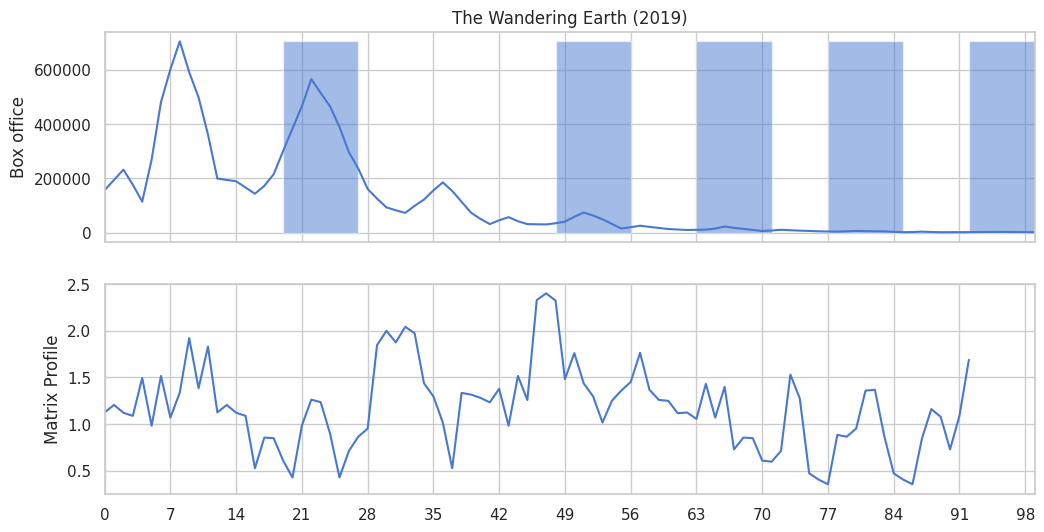

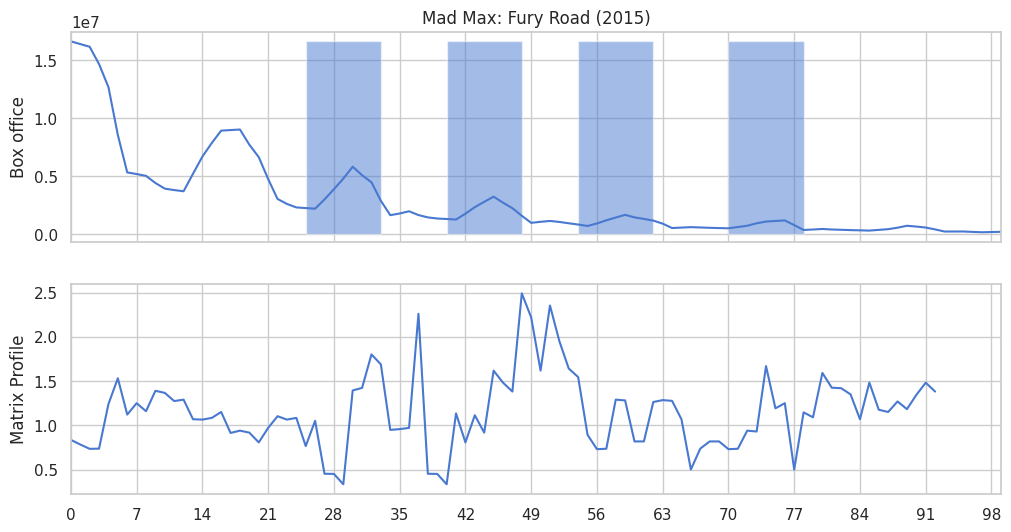

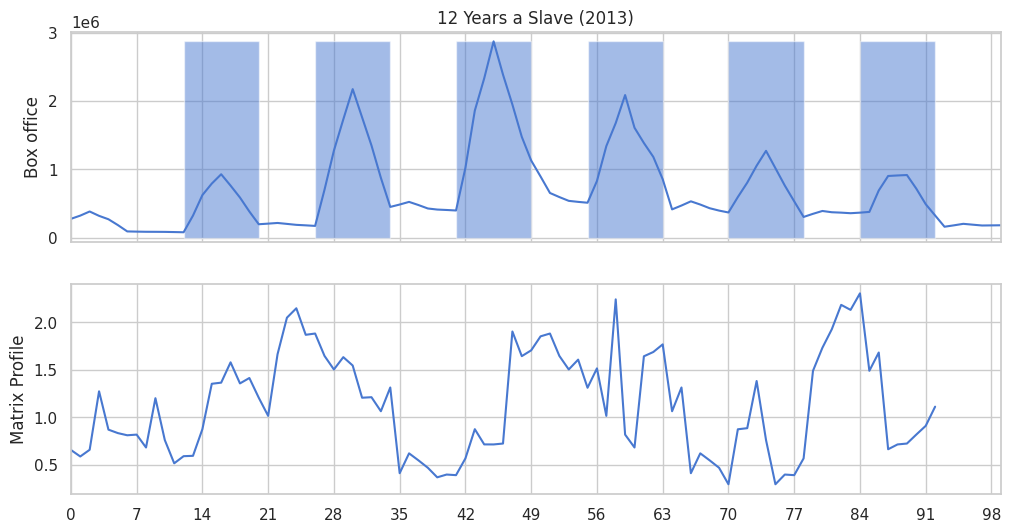

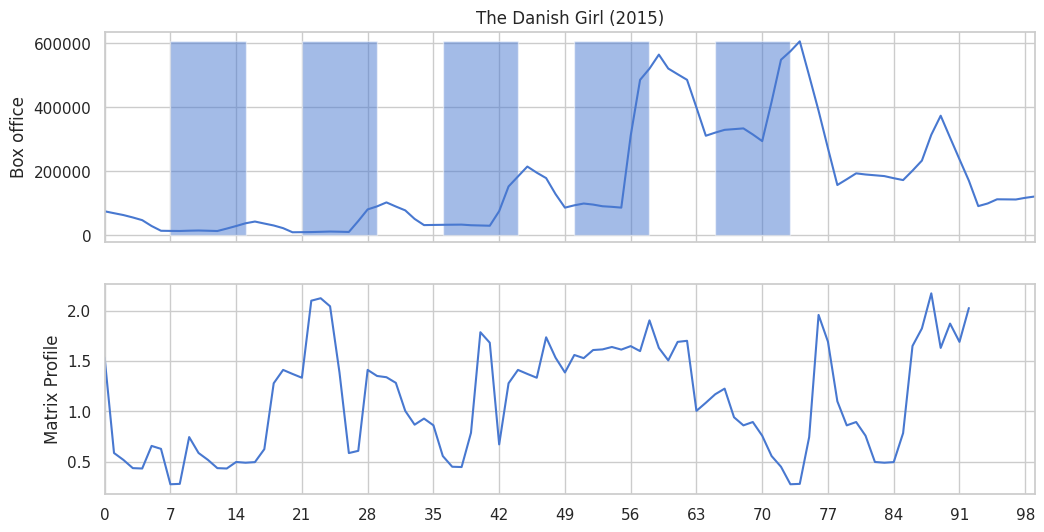

In [15]:
for movie_id in shape_medoids:
    plot_motifs(movie_id)

### Structural features-based clustering medoids

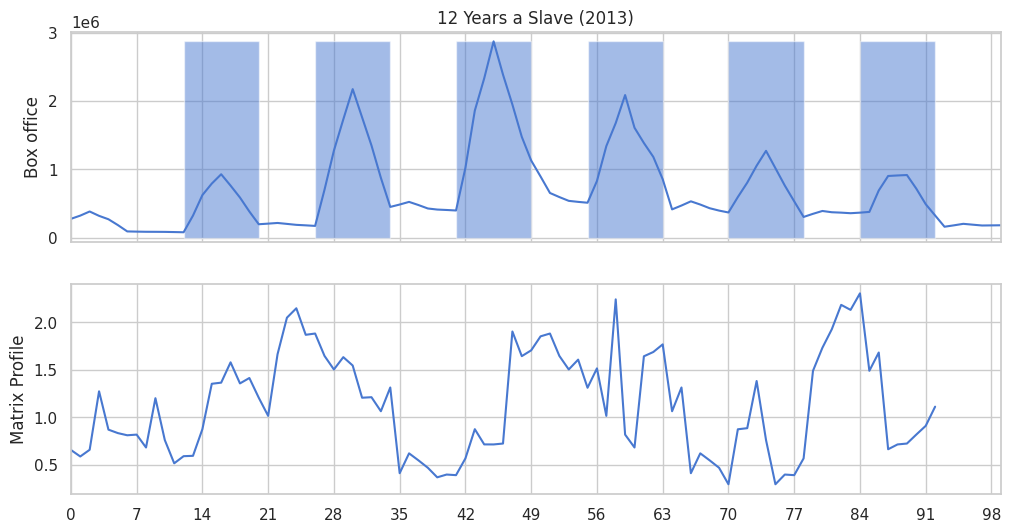

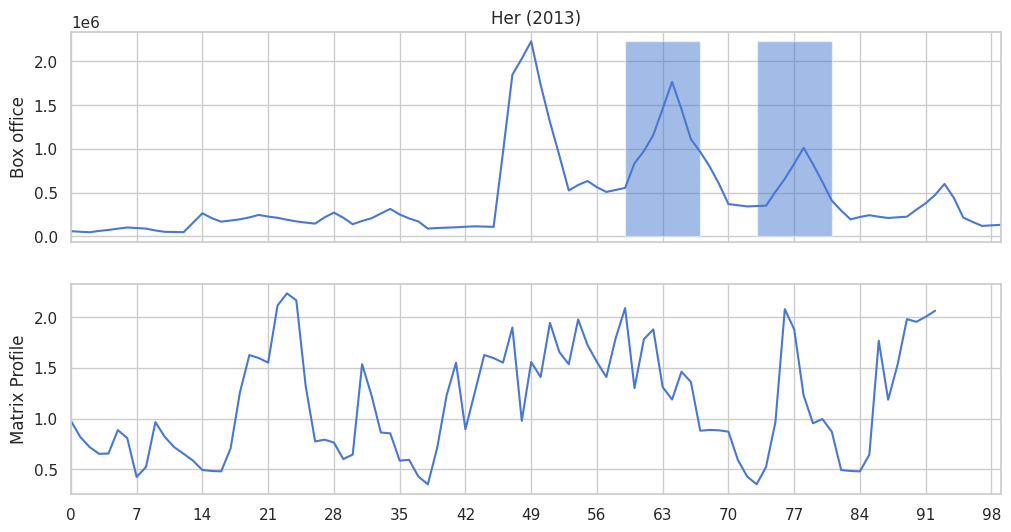

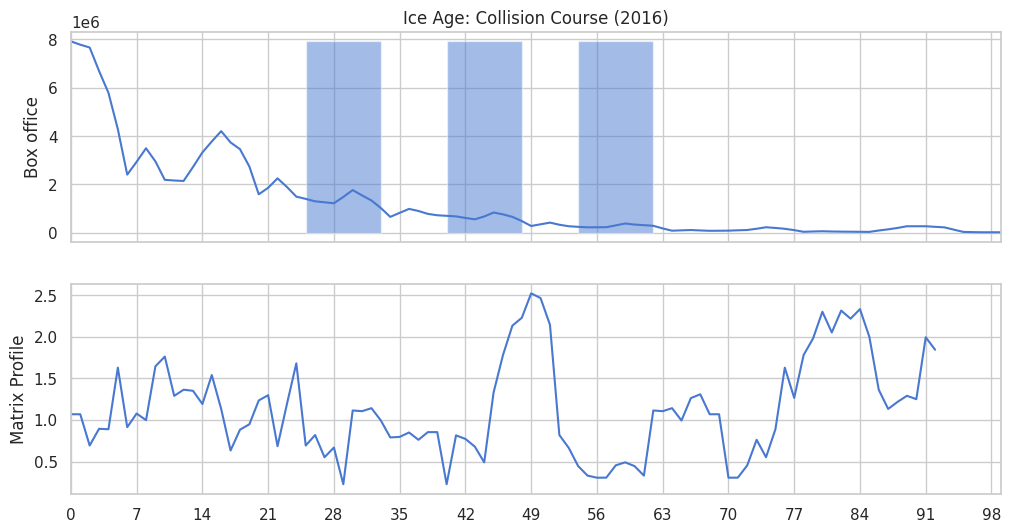

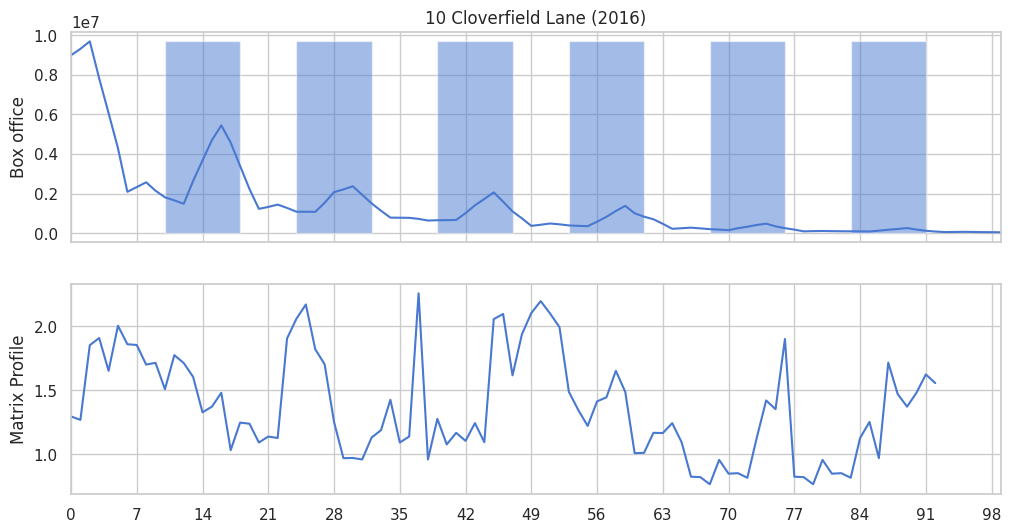

In [16]:
for movie in structure_medoids:
    plot_motifs(movie)